In [43]:

import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as np
from jax import vmap, jit

import numpy as onp
import pandas as pd
#from scipy.integrate import odeint
from scipy.special import gammaln
import pandas as pd
from matplotlib import pyplot as plt
import os

# modules from particles
import particles  # core module
from particles import distributions as dists  # where probability distributions are defined
from particles import state_space_models as ssm  # where state-space models are defined
from particles.collectors import Moments
from particles import mcmc  # where the MCMC algorithms (PMMH, Particle Gibbs, etc) live

from diffrax import diffeqsolve, ODETerm, Tsit5, SaveAt, PIDController
import numpy as onp


In [44]:
## particles only works with an old version of scipy

%load_ext watermark
%watermark -n -u -v -iv -w

The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark
Last updated: Fri, 09 Oct 2026

Python implementation: CPython
Python version       : 3.13.5
IPython version      : 9.17.1

diffrax   : 0.7.2
jax       : 0.5.3
matplotlib: 3.11.2
numpy     : 1.26.4
pandas    : 3.0.6
particles : 0.4

Watermark: 2.6.0



In [45]:
plt.style.use('default')
plt.style.use('seaborn-v0_8-paper')
plt.style.use('dark_background')


In [46]:

# we will carry out the simulations on proportions, and convert to per 100K rates
@jit
def simple_flu(t, x, p):
    # unpack vectors
    beta, gamma, delta, epsilon, theta, mu = p
    S, V, I, H, R, H_cum = x

    # Force of infection
    lambda_inf = beta*I

    dS_dt = -lambda_inf*S - delta*S
    dV_dt = -epsilon*lambda_inf*V + delta*S
    dI_dt = lambda_inf*(S + epsilon*V) - gamma*I
    dH_dt = gamma*theta*I - mu*H
    dR_dt = gamma*(1 - theta)*I + mu*H
    dH_cum_dt = gamma*theta*I

    return np.array([dS_dt,dV_dt,dI_dt,dH_dt,dR_dt,dH_cum_dt])

## create objects for ode solver
odeterm = ODETerm(simple_flu)
odesolver = Tsit5()
odestepsize = PIDController(rtol=1e-6, atol=1e-6)

## used in PX() of state space model:
@jit
def onestep(prev, p):
    deltaT = 7.0
    ## leaving out "saveat" saves only t1
    next = diffeqsolve(odeterm, odesolver, t0=0., t1=deltaT, dt0=None, y0=prev, args=p, stepsize_controller=odestepsize)
    return next.ys[0]

## vectorizes and jax-compiles onestep() for calling on a batch of particles
## the particles are a matrix with dims [# particles, # compartments]
## returns a matrix with same shape
batch_onestep = jit(vmap(onestep, in_axes=(0,None)))


In [47]:
class BetaFirst(dists.ProbDist):
    def __init__(self, beta_0, beta_1, fixed):
        self.beta_0 = beta_0
        self.beta_1 = beta_1
        self.alpha = np.array([beta_0, beta_1])
        self.fixed = fixed
        self._log_norm = gammaln(self.alpha.sum()) - gammaln(self.alpha).sum()
        self.remainder = 1.0-fixed[0]
        self.key = jax.random.key(onp.random.randint(1,10**6))

    # def rvs(self, size=None):
    #     shape = () if size is None else (size,)
    #     scale = 1-self.fixed[0]  # how much room is left for S and V
    #     x = jax.random.beta(key, self.beta_0, self.beta_1, shape=shape)
    #     if size is None:
    #         return np.concatenate((scale*x, scale*(1-x), self.fixed))
    #     tail = np.broadcast_to(self.fixed, (size, 3))
    #     return np.concatenate((x, tail), axis=-1)

    def rvs(self, size=None):
        fixed = np.asarray(self.fixed)

        shape = () if size is None else (size,)
        x = jax.random.beta(self.key, self.beta_0, self.beta_1, shape=shape)

        if size is None:
            sv = np.stack((self.remainder * x, self.remainder * (1.0 - x)))
            return np.concatenate((sv, fixed), axis=0)

        sv = np.stack((self.remainder * x, self.remainder * (1.0 - x)), axis=-1)
        tail = np.broadcast_to(fixed, (size, fixed.shape[0]))
        return np.concatenate((sv, tail), axis=-1)
    
    def logpdf(self, x):
            x = np.asarray(x)
            first = x[..., :2]
            tail = x[..., 2:]

            # Density is zero outside the Dirichlet simplex or when the
            # final three values do not equal the fixed values.
            valid = (
                np.all(first > 0, axis=-1)
                & np.isclose(first.sum(axis=-1), self.remainder)
                & np.all(np.isclose(tail, self.fixed), axis=-1)
            )
            lp = -np.log(self.remainder) + self._log_norm + np.sum((self.alpha - 1) * np.log(first/self.remainder), axis=-1)
            return np.where(valid, lp, -np.inf)

# simple LLM class
class Dirichlet(dists.ProbDist):
    def __init__(self, alpha):
        self.alpha = np.asarray(alpha, dtype=float)

        if self.alpha.ndim != 1 or self.alpha.size < 2:
            raise ValueError("alpha must be a 1D array with at least 2 values")
        if np.any(self.alpha <= 0):
            raise ValueError("all alpha values must be positive")

        self.dim = self.alpha.size
        self.dtype = np.dtype(float)
        self._log_norm = (
            gammaln(self.alpha.sum()) - gammaln(self.alpha).sum()
        )

    def rvs(self, size=None, key=key):
        shape = () if size is None else (size,)
        return jax.random.dirichlet(key, np.asarray(self.alpha), shape=shape)

    def logpdf(self, x):
        x = np.asarray(x, dtype=float)
        if x.shape[-1] != self.dim:
            raise ValueError(f"x must have final dimension {self.dim}")

        valid = (
            np.all(x > 0, axis=-1)
            & np.isclose(x.sum(axis=-1), 1.0)
        )

        with np.errstate(divide="ignore", invalid="ignore"):
            lp = self._log_norm + np.sum(
                (self.alpha - 1) * np.log(x), axis=-1
            )

        return np.where(valid, lp, -np.inf)

# LLM-generated probability distribution for the initial values
class DirichletWithFixedTail(dists.ProbDist):
    def __init__(self, alpha, fixed):
        self.alpha = np.asarray(alpha, dtype=float)
        self.fixed = np.asarray(fixed, dtype=float)

        if self.alpha.shape != (3,) or np.any(self.alpha <= 0):
            raise ValueError("alpha must contain 3 positive values")
        if self.fixed.shape != (3,):
            raise ValueError("fixed must contain 3 values")

        self.dim = 6
        self.dtype = np.dtype(float)

        # Normalizing constant for the 3-dimensional Dirichlet density
        self._log_norm = (
            gammaln(self.alpha.sum()) - gammaln(self.alpha).sum()
        )

    def rvs(self, size=None, key=key):
        shape = () if size is None else (size,)
        x = jax.random.dirichlet(key, np.asarray(self.alpha), shape=shape)
        if size is None:
            return np.concatenate((x, self.fixed))
        tail = np.broadcast_to(self.fixed, (size, 3))
        return np.concatenate((x, tail), axis=-1)

    def logpdf(self, x):
        x = np.asarray(x)
        first = x[..., :3]
        tail = x[..., 3:]

        # Density is zero outside the Dirichlet simplex or when the
        # final three values do not equal the fixed values.
        valid = (
            np.all(first > 0, axis=-1)
            & np.isclose(first.sum(axis=-1), 1.0)
            & np.all(np.isclose(tail, self.fixed), axis=-1)
        )
        with np.errstate(divide="ignore", invalid="ignore"):
            lp = self._log_norm + np.sum(
                (self.alpha - 1) * np.log(first), axis=-1
            )
        return np.where(valid, lp, -np.inf)

In [48]:
thingy = BetaFirst(8,8,[0.01,0,0,1e-9])
print(thingy.rvs(5))

[[6.08735255e-01 3.81264745e-01 1.00000000e-02 0.00000000e+00
  0.00000000e+00 1.00000000e-09]
 [3.54721512e-01 6.35278488e-01 1.00000000e-02 0.00000000e+00
  0.00000000e+00 1.00000000e-09]
 [4.83666624e-01 5.06333376e-01 1.00000000e-02 0.00000000e+00
  0.00000000e+00 1.00000000e-09]
 [3.31319600e-01 6.58680400e-01 1.00000000e-02 0.00000000e+00
  0.00000000e+00 1.00000000e-09]
 [3.64052711e-01 6.25947289e-01 1.00000000e-02 0.00000000e+00
  0.00000000e+00 1.00000000e-09]]


In [ ]:

# Note to self: vector-valued inputs to parameters for univariate distributions yields one distribution for each value
# which is used when you evaluate for each particle
inf_frac = 10**-3
certainty = 5*10**0
class FluPart(ssm.StateSpaceModel):

    default_params = {'beta':0.8,'gamma':0.2,'epsilon':0.05,
                    'delta':0.0,'theta':0.35,'mu':0.2,'sigma_meas':0.1,
                    'beta_dist_vec':np.array([8,8]),
                    'fixed_vec': np.array([0.0001,0.0,0.0,1e-9])}

    def PX0(self):  # Distribution of X_0
        # S = dists.Beta(1,1)
        # V = dists.LinearD(S, a=-1., b=0.99)
        # I = dists.Dirac(loc=0.01)
        # H = dists.Dirac(loc=0.0)
        # R = dists.Dirac(loc=0.0)
        # H_cum = dists.Dirac(loc=1e-9)
        # # nonS = np.array([0.47,0.001,0,0])  # V,I,H,R
        # # y0 = np.array([1.0 - np.sum(nonS), *nonS, 1e-9])
        # component_distributions = [S,V,I,H,R,H_cum]
        # return dists.IndepProd(*component_distributions)
        
        return BetaFirst(*self.beta_dist_vec, self.fixed_vec)

    def PX(self, t, xp):  # Distribution of X_t given X_{t-1}=xp (p=past)
        p = [self.beta, self.gamma, self.delta, self.epsilon, self.theta, self.mu]
        totals = batch_onestep(xp, p)
        component_distributions = [dists.Dirac(loc=totals[:, j]) for j in range(totals.shape[1])]
        return dists.IndepProd(*component_distributions)
        
    def PY(self, t, xp, x):  # Distribution of Y_t given X_t=x (and possibly X_{t-1}=xp)
        ## xp is unavailable at t0
        y = x[:,5] if xp is None else (x[:,5] - xp[:,5])
        return dists.LogNormal(mu=np.log(y+1e-9), sigma=self.sigma_meas)


In [50]:

#construct a prior for our model

##
## note: sampling fails with any dirac priors
## for fixed params, leave out of prior and set inside model
##
prior_dict = {
        "beta": dists.Gamma(4.0,6.0),  # likely using alpha-beta parametrization, mean = a/b
        "theta": dists.Beta(21.0,40.0),
        "sigma_meas": dists.Gamma(10.0,1000.0)
        }

# definition of model and prior
my_prior = dists.StructDist(prior_dict)

In [51]:
# acquire data
datafile = os.path.join("C:\\", "Users", "User", "python_code", "start_point", "nbeats_flu", "data", "FluSurveillance_Custom_Download_Data.csv")
#C:\Users\User\python_code\start_point\nbeats_flu\data\FluSurveillance_Custom_Download_Data.csv

# cumulative rate hospitalized is per one hundred thousand, so we normalize all data sources by 10**5
usecols=["YEAR", "WEEK", "AGE CATEGORY", "RACE CATEGORY", "SEX CATEGORY", "VIRUS TYPE CATEGORY", "CUMULATIVE RATE"]
df = pd.read_csv(datafile, usecols=usecols)
overall_data = df[df["AGE CATEGORY"]=="Overall"]
overall_data = overall_data[overall_data["RACE CATEGORY"]=="Overall"]
overall_data = overall_data[overall_data["SEX CATEGORY"]=="Overall"].reset_index(drop=True)
flu_A = overall_data[overall_data["VIRUS TYPE CATEGORY"]=="Influenza A"].reset_index(drop=True)
flu_B = overall_data[overall_data["VIRUS TYPE CATEGORY"]=="Influenza B"].reset_index(drop=True)
both = overall_data[overall_data["VIRUS TYPE CATEGORY"]=="Overall"].reset_index(drop=True)

flu_A_cases = np.array(flu_A["CUMULATIVE RATE"])/10**5
flu_A_incident = np.diff(flu_A_cases[30:60], prepend=0.0) + 1e-9 # 30:60 is 2010 flu season
flu_B_cases = np.array(flu_B["CUMULATIVE RATE"])/10**5
flu_B_incident = np.diff(flu_B_cases[30:60], prepend=0.0) + 1e-9
both_cases = np.array(both["CUMULATIVE RATE"])/10**5
time_series = both_cases[30:60]
incident_cases = np.diff(time_series, prepend=0.0) + 1e-9
both_strain_incident = np.stack([flu_A_incident, flu_B_incident])


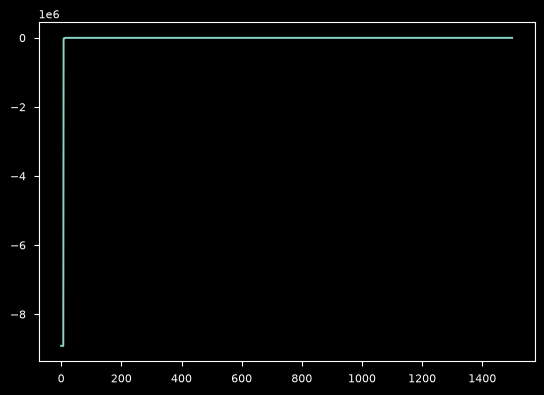

In [52]:
# perform filtering for full problem
pmmh = mcmc.PMMH(ssm_cls=FluPart, prior=my_prior, data=incident_cases, Nx=50, niter = 1500)
pmmh.run()
plt.plot(pmmh.chain.lpost)

In [53]:
print(pmmh.chain.lpost)

[-8.91490288e+06 -8.91490288e+06 -8.91490288e+06 ... -7.51637575e+02
 -7.51637575e+02 -7.51637575e+02]


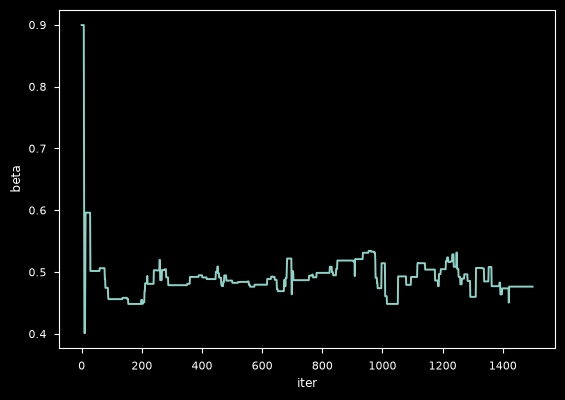

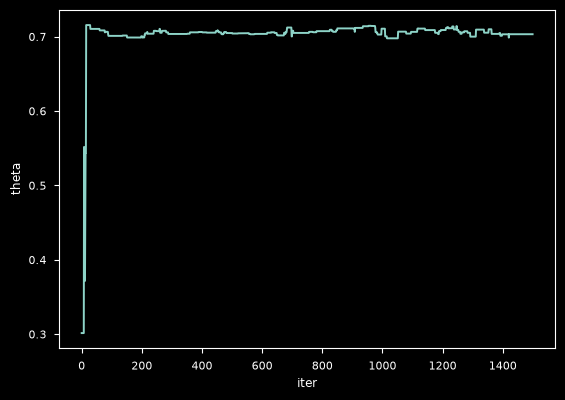

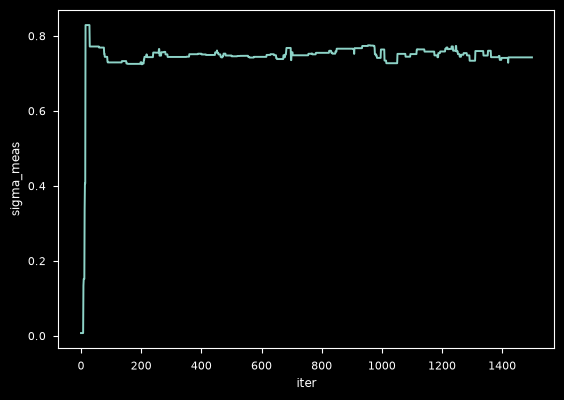

In [54]:
for p in prior_dict.keys():  # loop over mu, theta, rho
     plt.figure()
     plt.plot(pmmh.chain.theta[p])
     plt.xlabel('iter')
     plt.ylabel(p)
     plt.show()

In [55]:
print(pmmh.chain.theta["theta"])

[0.30150823 0.30150823 0.30150823 ... 0.70331828 0.70331828 0.70331828]


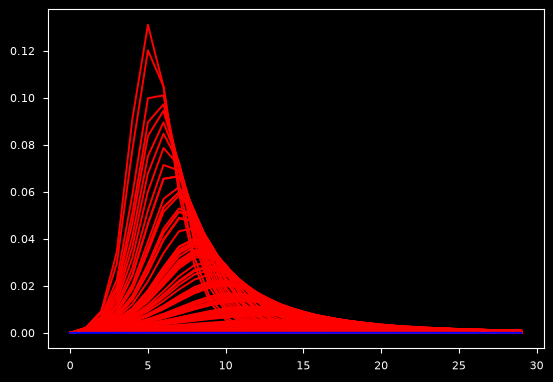

In [59]:
# get parameter estimates for goodness of fit
from copy import deepcopy
from jax.experimental.ode import odeint

parameter_results = deepcopy(FluPart().default_params)
for p in prior_dict.keys():  # loop over mu, theta, rho
     parameter_results[p] = np.mean(pmmh.chain.theta[p][500:])

par_vec = [parameter_results["beta"], parameter_results["gamma"], parameter_results["delta"], 
           parameter_results["epsilon"], parameter_results["theta"], parameter_results["mu"]]
num_weeks = len(incident_cases)

# solve ODE
deltaT = 7.0
num_ics = 100
timepoints = np.array([i*deltaT for i in range(0,num_weeks)])
init_conds = BetaFirst(*parameter_results["beta_dist_vec"],parameter_results["fixed_vec"]).rvs(size=num_ics)
def f_for_odeint(y,t,p):
     return simple_flu(t,y,p)

for ic in init_conds:
     ys = odeint(f_for_odeint, ic, timepoints, par_vec)
     cum_hosp = ys[:,5]
     inc_hosp = np.diff(cum_hosp, prepend=0.0)
     plt.plot(inc_hosp, color="red")
plt.plot(incident_cases, color="blue")
plt.show()